# Default Parameters

In [89]:
filename = "bank-full.csv"
target_variable_name = "y"

# Load Dataset

In [90]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
df = spark.read.csv(filename, header=True, inferSchema=True, sep=';')
df.show()

+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

# Data Exploration

## Length of the data

In [91]:
df.count()

45211

## Describe data

In [92]:
df.describe().toPandas()

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


## Check Data types of each column

In [93]:
df.dtypes

[('age', 'int'),
 ('job', 'string'),
 ('marital', 'string'),
 ('education', 'string'),
 ('default', 'string'),
 ('balance', 'int'),
 ('housing', 'string'),
 ('loan', 'string'),
 ('contact', 'string'),
 ('day', 'int'),
 ('month', 'string'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('poutcome', 'string'),
 ('y', 'string')]

In [94]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## Count the records by group

In [95]:
df.groupBy('education').count().show()

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+



## Count the records by target

In [96]:
df.groupBy(target_variable_name).count().show()

+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+



## Group by Multiple columns

In [97]:
df.groupBy(['education',target_variable_name]).count().show()

+---------+---+-----+
|education|  y|count|
+---------+---+-----+
|  unknown| no| 1605|
| tertiary| no|11305|
|secondary| no|20752|
|  unknown|yes|  252|
|  primary| no| 6260|
|  primary|yes|  591|
|secondary|yes| 2450|
| tertiary|yes| 1996|
+---------+---+-----+



In [98]:
from pyspark.sql.functions import * 
df.groupBy(target_variable_name).agg({'balance':'avg', 'age': 'avg'}).show()

+---+------------------+------------------+
|  y|      avg(balance)|          avg(age)|
+---+------------------+------------------+
| no|1303.7149691899203| 40.83898602274435|
|yes|1804.2679145396105|41.670069956513515|
+---+------------------+------------------+



## Cardinality Check

In [99]:
from pyspark.sql.functions import approxCountDistinct, countDistinct

"""
Note: approxCountDistinct and countDistinct can be used interchangeably. Only difference is the computation time. 

"approxCountDistinct" is useful for large datasets 
"countDistinct" for small and medium datasets.

"""

def cardinality_calculation(df, cut_off=1):
    cardinality = df.select(*[approxCountDistinct(c).alias(c) for c in df.columns])
    
    ## convert to pandas for efficient calculations
    final_cardinality_df = cardinality.toPandas().transpose()
    final_cardinality_df.reset_index(inplace=True) 
    final_cardinality_df.rename(columns={0:'Cardinality'}, inplace=True) 
    
    #select variables with cardinality of 1
    vars_selected = final_cardinality_df['index'][final_cardinality_df['Cardinality'] <= cut_off] 
    
    return final_cardinality_df, vars_selected

cardinality_df, cardinality_vars_selected = cardinality_calculation(df)

/usr/local/spark/python/pyspark/sql/functions.py:3796: FutureWarning: Deprecated in 2.1, use approx_count_distinct instead.
  warnings.warn("Deprecated in 2.1, use approx_count_distinct instead.", FutureWarning)


In [100]:
cardinality_df

,index,Cardinality
0,age,76
1,job,11
2,marital,3
3,education,4
4,default,2
5,balance,7375
6,housing,2
7,loan,2
8,contact,3
9,day,32


In [101]:
cardinality_vars_selected

Series([], Name: index, dtype: object)

### Pandas Way

In [102]:
df.toPandas().nunique(dropna=False)

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

## Missing value check

In [103]:
#missing values check
from pyspark.sql.functions import count, when, isnan, col

# miss_percentage is set to 80% as discussed in the book
def missing_calculation(df, miss_percentage=0.80):
    
    #checks for both NaN and null values
    missing = df.select(*[count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns])
    length_df = df.count()
    ## convert to pandas for efficient calculations
    final_missing_df = missing.toPandas().transpose()
    final_missing_df.reset_index(inplace=True) 
    final_missing_df.rename(columns={0:'missing_count'}, inplace=True) 
    final_missing_df['missing_percentage'] = final_missing_df['missing_count']/length_df
    
    #select variables with cardinality of 1
    vars_selected = final_missing_df['index'][final_missing_df['missing_percentage'] >= miss_percentage] 
    
    return final_missing_df, vars_selected

In [104]:
missing_df, missing_vars_selected = missing_calculation(df)

In [105]:
missing_df

,index,missing_count,missing_percentage
0,age,0,0.0
1,job,0,0.0
2,marital,0,0.0
3,education,0,0.0
4,default,0,0.0
5,balance,0,0.0
6,housing,0,0.0
7,loan,0,0.0
8,contact,0,0.0
9,day,0,0.0


In [106]:
missing_vars_selected

Series([], Name: index, dtype: object)

### Using Pandas

In [107]:
df.toPandas().isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## Identify variable types

In [108]:
def variable_type(df):
    
    vars_list = df.dtypes
    char_vars = []
    num_vars = []
    for i in vars_list:
        if i[1] in ('string'):
            char_vars.append(i[0])
        else:
            num_vars.append(i[0])
    
    return char_vars, num_vars

In [109]:
char_vars, num_vars = variable_type(df)

In [110]:
char_vars

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [111]:
num_vars

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Label Encoding

In [112]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

def category_to_index(df, char_vars):
    
    char_df = df.select(char_vars)
    indexers = [StringIndexer(inputCol=c, outputCol=c+"_index", handleInvalid="keep") for c in char_df.columns]
    pipeline = Pipeline(stages=indexers)
    char_labels = pipeline.fit(char_df)
    df = char_labels.transform(df)
    return df, char_labels

In [113]:
df, char_labels = category_to_index(df, char_vars)

In [114]:
df.dtypes

[('age', 'int'),
 ('job', 'string'),
 ('marital', 'string'),
 ('education', 'string'),
 ('default', 'string'),
 ('balance', 'int'),
 ('housing', 'string'),
 ('loan', 'string'),
 ('contact', 'string'),
 ('day', 'int'),
 ('month', 'string'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('poutcome', 'string'),
 ('y', 'string'),
 ('job_index', 'double'),
 ('marital_index', 'double'),
 ('education_index', 'double'),
 ('default_index', 'double'),
 ('housing_index', 'double'),
 ('loan_index', 'double'),
 ('contact_index', 'double'),
 ('month_index', 'double'),
 ('poutcome_index', 'double'),
 ('y_index', 'double')]

In [115]:
df = df.select([c for c in df.columns if c not in char_vars])

In [116]:
def rename_columns(df, char_vars):
    mapping = dict(zip([i + '_index' for i in char_vars], char_vars))
    df = df.select([col(c).alias(mapping.get(c, c)) for c in df.columns])
    return df

In [117]:
df = rename_columns(df, char_vars)

In [118]:
df.dtypes

[('age', 'int'),
 ('balance', 'int'),
 ('day', 'int'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('job', 'double'),
 ('marital', 'double'),
 ('education', 'double'),
 ('default', 'double'),
 ('housing', 'double'),
 ('loan', 'double'),
 ('contact', 'double'),
 ('month', 'double'),
 ('poutcome', 'double'),
 ('y', 'double')]

# Assemble input vectors

## No Scaling Input Vectors

In [119]:
from pyspark.ml.feature import VectorAssembler

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features'] + features_list
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

In [120]:
#exclude target variable and select all other feature vectors
features_list = df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)

In [121]:
features_list

['age',
 'balance',
 'day',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [122]:
# apply the function on our dataframe
df_features = assemble_vectors(df, features_list, target_variable_name)

In [123]:
df_features.show()

+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+
|  y|            features|age|balance|day|duration|campaign|pdays|previous| job|marital|education|default|housing|loan|contact|month|poutcome|
+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+
|0.0|(16,[0,1,2,3,4,5,...| 58|   2143|  5|     261|       1|   -1|       0| 1.0|    0.0|      1.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 44|     29|  5|     151|       1|   -1|       0| 2.0|    1.0|      0.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 33|      2|  5|      76|       1|   -1|       0| 7.0|    0.0|      0.0|    0.0|    0.0| 1.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 47|   1506|  5|      92|       1|   -1|       0| 0.0|    0.0|      3.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|

In [124]:
df_features.schema["features"].metadata["ml_attr"]["attrs"]

{'numeric': [{'idx': 0, 'name': 'age'},
  {'idx': 1, 'name': 'balance'},
  {'idx': 2, 'name': 'day'},
  {'idx': 3, 'name': 'duration'},
  {'idx': 4, 'name': 'campaign'},
  {'idx': 5, 'name': 'pdays'},
  {'idx': 6, 'name': 'previous'}],
 'nominal': [{'vals': ['blue-collar',
    'management',
    'technician',
    'admin.',
    'services',
    'retired',
    'self-employed',
    'entrepreneur',
    'unemployed',
    'housemaid',
    'student',
    'unknown',
    '__unknown'],
   'idx': 7,
   'name': 'job'},
  {'vals': ['married', 'single', 'divorced', '__unknown'],
   'idx': 8,
   'name': 'marital'},
  {'vals': ['secondary', 'tertiary', 'primary', 'unknown', '__unknown'],
   'idx': 9,
   'name': 'education'},
  {'vals': ['no', 'yes', '__unknown'], 'idx': 10, 'name': 'default'},
  {'vals': ['yes', 'no', '__unknown'], 'idx': 11, 'name': 'housing'},
  {'vals': ['no', 'yes', '__unknown'], 'idx': 12, 'name': 'loan'},
  {'vals': ['cellular', 'unknown', 'telephone', '__unknown'],
   'idx': 13,


In [125]:
import pandas as pd
for k, v in df_features.schema["features"].metadata["ml_attr"]["attrs"].items():
    features_df = pd.DataFrame(v)

## Scaled input vectors assembled

In [126]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

#assemble and scale individual columns to one column - 'features2'
def scaled_assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='assembled_features')
    scaler = StandardScaler(inputCol=assembler.getOutputCol(), outputCol='features2')
    stages = [assembler, scaler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features2'] + features_list
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    scaleAssembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = scaleAssembleModel.transform(df).select(selectedCols)
    return df

In [127]:
features_list = df.columns
features_list.remove(target_variable_name)

In [128]:
df_scaled_features = scaled_assemble_vectors(df, features_list, target_variable_name)

In [129]:
df_scaled_features.show()

+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+
|  y|           features2|age|balance|day|duration|campaign|pdays|previous| job|marital|education|default|housing|loan|contact|month|poutcome|
+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+
|0.0|(16,[0,1,2,3,4,5,...| 58|   2143|  5|     261|       1|   -1|       0| 1.0|    0.0|      1.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 44|     29|  5|     151|       1|   -1|       0| 2.0|    1.0|      0.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 33|      2|  5|      76|       1|   -1|       0| 7.0|    0.0|      0.0|    0.0|    0.0| 1.0|    1.0|  0.0|     0.0|
|0.0|(16,[0,1,2,3,4,5,...| 47|   1506|  5|      92|       1|   -1|       0| 0.0|    0.0|      3.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|

# Variable Selection

## Inbuilt variable selection process – Without Target

### Principal Component analysis

In [130]:
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors

pca = PCA(k=3, inputCol="features", outputCol="pcaFeatures")
model = pca.fit(df_features)

result = model.transform(df_features).select("pcaFeatures")
result.show(truncate=False)

+------------------------------------------------------------+
|pcaFeatures                                                 |
+------------------------------------------------------------+
|[-2143.49536477358,-257.0420740676506,1.2449712753048212]   |
|[-29.292261751646247,-150.92888640669176,1.0493026899279954]|
|[-2.150889773941864,-75.98191250436618,1.0760651955381273]  |
|[-1506.182330590811,-89.21547154672702,1.2683999536976267]  |
|[-1.3750908349448097,-197.98356175494837,0.9892427009816462]|
|[-231.26679712386607,-138.56034919503722,1.057696089139632] |
|[-447.4072782675638,-216.16541383839757,1.0066666548031264] |
|[-2.7123264447442086,-379.97858281643573,0.8751504698368263]|
|[-121.1114484821404,-49.756360259707826,1.1725853591924094] |
|[-593.1146061641072,-53.89364261832036,1.1817022732262148]  |
|[-270.42123413234157,-221.48699661827928,1.0170824073205804]|
|[-390.2608167665407,-136.2701690933914,1.062533686269987]   |
|[-6.967616100129167,-516.96745582487,0.800354576807158

In [131]:
model.pc.toArray()

array([[-3.41021399e-04,  2.79524640e-04,  2.58353293e-03],
       [-9.99998245e-01,  1.83654726e-03,  1.13892524e-04],
       [-1.22934480e-05,  9.79995613e-04,  7.79347982e-03],
       [-1.83671689e-03, -9.99996986e-01, -7.36955549e-04],
       [ 1.48468991e-05,  1.01391994e-03,  2.75121381e-03],
       [-1.13085547e-04,  7.49207153e-04, -9.99889046e-01],
       [-1.26153895e-05, -6.36100089e-06, -1.04654388e-02],
       [-1.78789640e-05, -4.11817349e-05,  5.51411389e-04],
       [ 6.41085932e-06, -5.23364803e-05, -1.45349520e-04],
       [-1.11185424e-05,  1.30366514e-05,  2.01500982e-04],
       [ 2.91665702e-06,  4.42643869e-06,  3.95562163e-05],
       [-1.12221341e-05,  1.26153926e-05,  6.17569266e-04],
       [ 1.01623400e-05,  1.50687571e-05,  8.23933054e-05],
       [-5.68377754e-07,  6.95393403e-05,  1.03951369e-03],
       [-7.60886236e-05, -1.16754927e-04, -3.24662847e-03],
       [-8.55162111e-06, -6.01853226e-05, -4.94522998e-03]])

In [132]:
model.explainedVariance

DenseVector([0.9918, 0.0071, 0.0011])

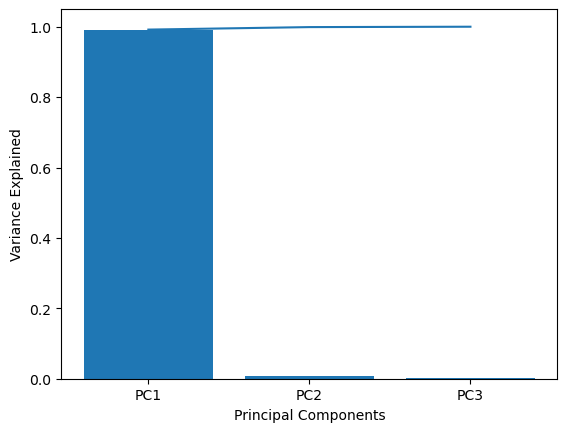

In [133]:
import matplotlib.pyplot as plt
import numpy as np
x = []
for i in range(0, len(model.explainedVariance)):
    x.append('PC' + str(i + 1))
y = np.array(model.explainedVariance)
z = np.cumsum(model.explainedVariance)
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.bar(x, y)
plt.plot(x, z)

### Singular Value Decomposition

In [134]:
df_svd_vector = df_features.rdd.map(lambda x: x['features'].toArray())

In [135]:
df_svd_vector

PythonRDD[483] at RDD at PythonRDD.scala:53

In [136]:
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.linalg.distributed import RowMatrix

mat = RowMatrix(df_svd_vector)

# Compute the top 5 singular values and corresponding singular vectors.
svd = mat.computeSVD(5, computeU=True)
U = svd.U       # The U factor is a RowMatrix.
s = svd.s       # The singular values are stored in a local dense vector.
V = svd.V       # The V factor is a local dense matrix.

## Inbuilt variable selection process – With Target

### ChiSq selector

In [137]:
from pyspark.ml.feature import ChiSqSelector
from pyspark.ml.linalg import Vectors

selector = ChiSqSelector(numTopFeatures=6, featuresCol="features",
                         outputCol="selectedFeatures", labelCol="y")

chi_selector = selector.fit(df_features)
    
result = chi_selector.transform(df_features)

print("ChiSqSelector output with top %d features selected" % selector.getNumTopFeatures())
print("Selected Indices: ", chi_selector.selectedFeatures)
result.show()

ChiSqSelector output with top 6 features selected
Selected Indices:  [0, 1, 2, 3, 4, 5]
+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+--------------------+
|  y|            features|age|balance|day|duration|campaign|pdays|previous| job|marital|education|default|housing|loan|contact|month|poutcome|    selectedFeatures|
+---+--------------------+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+--------------------+
|0.0|(16,[0,1,2,3,4,5,...| 58|   2143|  5|     261|       1|   -1|       0| 1.0|    0.0|      1.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|(6,[0,1,2,3,4,5],...|
|0.0|(16,[0,1,2,3,4,5,...| 44|     29|  5|     151|       1|   -1|       0| 2.0|    1.0|      0.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|(6,[0,1,2,3,4,5],...|
|0.0|(16,[0,1,2,3,4,5,...| 33|      2|  5|      76|       1|   -1|       0| 7.0|    0.0|    

In [138]:
chi_selector.selectedFeatures

[0, 1, 2, 3, 4, 5]

In [139]:
features_df['chisq_importance'] = features_df['idx'].apply(lambda x: 1 if x in chi_selector.selectedFeatures else 0)

In [140]:
features_df

,vals,idx,name,chisq_importance
0,"[blue-collar, management, technician, admin., ...",7,job,0
1,"[married, single, divorced, __unknown]",8,marital,0
2,"[secondary, tertiary, primary, unknown, __unkn...",9,education,0
3,"[no, yes, __unknown]",10,default,0
4,"[yes, no, __unknown]",11,housing,0
5,"[no, yes, __unknown]",12,loan,0
6,"[cellular, unknown, telephone, __unknown]",13,contact,0
7,"[may, jul, aug, jun, nov, apr, feb, jan, oct, ...",14,month,0
8,"[unknown, failure, other, success, __unknown]",15,poutcome,0


## Model based feature selection

In [141]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol='features', labelCol=target_variable_name)
rf_model = rf.fit(df_features)
rf_model.featureImportances

SparseVector(16, {0: 0.0038, 1: 0.005, 2: 0.0042, 3: 0.4528, 4: 0.0038, 5: 0.049, 6: 0.0241, 7: 0.0053, 8: 0.002, 9: 0.0011, 10: 0.0, 11: 0.0437, 12: 0.0014, 13: 0.0284, 14: 0.1519, 15: 0.2236})

In [142]:
#temporary output rf_output
rf_output = rf_model.featureImportances
features_df['Importance'] = features_df['idx'].apply(lambda x: rf_output[x] if x in rf_output.indices else 0)

In [143]:
#sort values based on descending importance feature
features_df.sort_values("Importance", ascending=False, inplace=True)

In [144]:
features_df

,vals,idx,name,chisq_importance,Importance
8,"[unknown, failure, other, success, __unknown]",15,poutcome,0,0.223572
7,"[may, jul, aug, jun, nov, apr, feb, jan, oct, ...",14,month,0,0.151893
4,"[yes, no, __unknown]",11,housing,0,0.043665
6,"[cellular, unknown, telephone, __unknown]",13,contact,0,0.028414
0,"[blue-collar, management, technician, admin., ...",7,job,0,0.005339
1,"[married, single, divorced, __unknown]",8,marital,0,0.001954
5,"[no, yes, __unknown]",12,loan,0,0.001372
2,"[secondary, tertiary, primary, unknown, __unkn...",9,education,0,0.001069
3,"[no, yes, __unknown]",10,default,0,0.000040


Text(0, 0.5, 'Variable Importance')

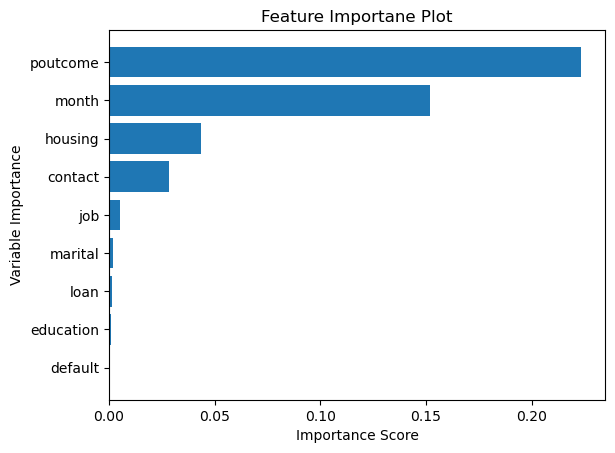

In [145]:
import matplotlib.pyplot as plt

features_df.sort_values("Importance", ascending=True, inplace=True)
plt.barh(features_df['name'], features_df['Importance'])
plt.title("Feature Importane Plot")
plt.xlabel("Importance Score")
plt.ylabel("Variable Importance")

### Correlation function

In [146]:
from pyspark.mllib.stat import Statistics

correlation_type = 'pearson' # 'pearson', 'spearman'

In [147]:
column_names = dict()

for k, v in df_features.schema["features"].metadata["ml_attr"]["attrs"].items():
    print(v)
    features_df = pd.DataFrame(v)
    column_names.update(dict(zip(features_df['idx'], features_df['name'])))

[{'idx': 0, 'name': 'age'}, {'idx': 1, 'name': 'balance'}, {'idx': 2, 'name': 'day'}, {'idx': 3, 'name': 'duration'}, {'idx': 4, 'name': 'campaign'}, {'idx': 5, 'name': 'pdays'}, {'idx': 6, 'name': 'previous'}]
[{'vals': ['blue-collar', 'management', 'technician', 'admin.', 'services', 'retired', 'self-employed', 'entrepreneur', 'unemployed', 'housemaid', 'student', 'unknown', '__unknown'], 'idx': 7, 'name': 'job'}, {'vals': ['married', 'single', 'divorced', '__unknown'], 'idx': 8, 'name': 'marital'}, {'vals': ['secondary', 'tertiary', 'primary', 'unknown', '__unknown'], 'idx': 9, 'name': 'education'}, {'vals': ['no', 'yes', '__unknown'], 'idx': 10, 'name': 'default'}, {'vals': ['yes', 'no', '__unknown'], 'idx': 11, 'name': 'housing'}, {'vals': ['no', 'yes', '__unknown'], 'idx': 12, 'name': 'loan'}, {'vals': ['cellular', 'unknown', 'telephone', '__unknown'], 'idx': 13, 'name': 'contact'}, {'vals': ['may', 'jul', 'aug', 'jun', 'nov', 'apr', 'feb', 'jan', 'oct', 'sep', 'mar', 'dec', '__u

In [148]:
print(column_names)

{0: 'age', 1: 'balance', 2: 'day', 3: 'duration', 4: 'campaign', 5: 'pdays', 6: 'previous', 7: 'job', 8: 'marital', 9: 'education', 10: 'default', 11: 'housing', 12: 'loan', 13: 'contact', 14: 'month', 15: 'poutcome'}


In [149]:
df_vector = df_features.rdd.map(lambda x: x['features'].toArray())

In [150]:
matrix = Statistics.corr(df_vector, method=correlation_type)

In [151]:
import pandas as pd
corr_df = pd.DataFrame(matrix, columns=column_names, index=column_names)

In [152]:
corr_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.077468,-0.126351,0.167296,-0.017879,0.185513,-0.015655,0.122114,0.089717,0.012238
1,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.020404,-0.028172,0.039067,-0.066745,0.068768,-0.084350,0.002844,0.092853,0.037272
2,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.010874,-0.005217,-0.004675,0.009424,0.027982,0.011370,-0.006302,-0.038019,-0.072629
3,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.004410,0.018834,-0.003029,-0.010021,-0.005075,-0.012412,-0.029350,0.014097,0.023192
4,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.025450,-0.029294,0.018643,0.016822,0.023599,0.009980,0.046971,-0.093829,-0.094982
5,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,-0.020621,0.020832,-0.023103,-0.029979,-0.124178,-0.022754,-0.170654,0.130504,0.709008
6,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,-0.002425,0.006876,-0.007463,-0.018329,-0.037076,-0.011043,-0.091911,0.124014,0.485040
7,0.077468,0.020404,-0.010874,0.004410,-0.025450,-0.020621,-0.002425,1.000000,0.050184,-0.002546,-0.003261,0.175678,-0.035331,0.011959,0.116516,0.022384
8,-0.126351,-0.028172,-0.005217,0.018834,-0.029294,0.020832,0.006876,0.050184,1.000000,-0.061597,0.018404,0.011671,-0.018526,-0.038869,0.010914,0.020126
9,0.167296,0.039067,-0.004675,-0.003029,0.018643,-0.023103,-0.007463,-0.002546,-0.061597,1.000000,-0.007520,0.076023,-0.068765,0.062967,0.028758,-0.010689


In [153]:
final_corr_df = pd.DataFrame(corr_df.abs().unstack().sort_values(kind='quicksort')).reset_index()
final_corr_df.rename({'level_0': 'col1', 'level_1': 'col2', 0: 'correlation_value'}, axis=1, inplace=True)
final_corr_df = final_corr_df[final_corr_df['col1'] != final_corr_df['col2']]
final_corr_df

,col1,col2,correlation_value
0,11,15,0.000527
1,15,11,0.000527
2,10,13,0.000961
3,13,10,0.000961
4,3,6,0.001203
...,...,...,...
235,6,5,0.454820
236,15,6,0.485040
237,6,15,0.485040
238,15,5,0.709008


In [154]:
correlation_cutoff = 0.65 #custom parameter
final_corr_df[final_corr_df['correlation_value'] > correlation_cutoff]

,col1,col2,correlation_value
238,15,5,0.709008
239,5,15,0.709008


# Supervised Learning

In [155]:
df.show(5)

+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous| job|marital|education|default|housing|loan|contact|month|poutcome|  y|
+---+-------+---+--------+--------+-----+--------+----+-------+---------+-------+-------+----+-------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0| 1.0|    0.0|      1.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|0.0|
| 44|     29|  5|     151|       1|   -1|       0| 2.0|    1.0|      0.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|0.0|
| 33|      2|  5|      76|       1|   -1|       0| 7.0|    0.0|      0.0|    0.0|    0.0| 1.0|    1.0|  0.0|     0.0|0.0|
| 47|   1506|  5|      92|       1|   -1|       0| 0.0|    0.0|      3.0|    0.0|    0.0| 0.0|    1.0|  0.0|     0.0|0.0|
| 33|      1|  5|     198|       1|   -1|       0|11.0|    1.0|      3.0|    0.0|    1.0| 0.0|    1.0|  0.0|     0.0|0.0|
+---+-------+---+-------

In [157]:
linear_df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'])

In [159]:
target_variable_name = 'balance'

## Assemble Vectors

In [160]:
#exclude target variable and select all other feature vectors
features_list = linear_df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)

In [161]:
# apply the function on our dataframe
linear_df = assemble_vectors(linear_df, features_list, target_variable_name)

In [162]:
linear_df.show(5)

+-------+--------------------+---+---+--------+--------+-----+--------+
|balance|            features|age|day|duration|campaign|pdays|previous|
+-------+--------------------+---+---+--------+--------+-----+--------+
|   2143|[58.0,5.0,261.0,1...| 58|  5|     261|       1|   -1|       0|
|     29|[44.0,5.0,151.0,1...| 44|  5|     151|       1|   -1|       0|
|      2|[33.0,5.0,76.0,1....| 33|  5|      76|       1|   -1|       0|
|   1506|[47.0,5.0,92.0,1....| 47|  5|      92|       1|   -1|       0|
|      1|[33.0,5.0,198.0,1...| 33|  5|     198|       1|   -1|       0|
+-------+--------------------+---+---+--------+--------+-----+--------+
only showing top 5 rows



## Linear Regression

In [163]:
from pyspark.ml.regression import LinearRegression
reg = LinearRegression(featuresCol='features', labelCol='balance')
reg_model = reg.fit(linear_df) # fit model

In [164]:
import pandas as pd
column_names = dict()

for k, v in linear_df.schema["features"].metadata["ml_attr"]["attrs"].items():
    features_df = pd.DataFrame(v)
    column_names.update(dict(zip(features_df['idx'], features_df['name'])))

# Empty dataframe to store coefficients and add name from column_names
features_df = pd.DataFrame()
features_df['idx'] = column_names.keys()
features_df['name'] = column_names.values()

# print coefficient and intercept
print(reg_model.coefficients, reg_model.intercept)

features_df['coefficients'] = reg_model.coefficients

[28.08397290892997,3.3055463619496286,0.24882841970901756,-14.142676297161454,-0.08248810233032043,23.462992800762525] 124.92130092818479


In [165]:
features_df

,idx,name,coefficients
0,0,age,28.083973
1,1,day,3.305546
2,2,duration,0.248828
3,3,campaign,-14.142676
4,4,pdays,-0.082488
5,5,previous,23.462993


In [166]:
#prediction result
pred_result = reg_model.transform(linear_df)

In [167]:
pred_result

DataFrame[balance: int, features: vector, age: int, day: int, duration: int, campaign: int, pdays: int, previous: int, prediction: double]

In [168]:
reg_model.summary.r2

0.01056811651155165

In [169]:
features_list

['age', 'day', 'duration', 'campaign', 'pdays', 'previous']

### Variance Inflation factor

In [170]:
def vif_calculator(df, features_list):
    vif_list = []
    for i in features_list:
        temp_features_list = features_list.copy()
        temp_features_list.remove(i)
        temp_target = i
        assembler = VectorAssembler(inputCols=temp_features_list, outputCol='features')
        temp_df = assembler.transform(df)
        reg = LinearRegression(featuresCol='features', labelCol=i)
        reg_model = reg.fit(temp_df) # fit model
        temp_vif = 1/(1 - reg_model.summary.r2)
        vif_list.append(temp_vif)
    return vif_list

In [174]:
linear_df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'])

In [175]:
features_df['vif'] = vif_calculator(linear_df, features_list)

In [176]:
features_df

,idx,name,coefficients,vif
0,0,age,28.083973,1.000917
1,1,day,3.305546,1.034350
2,2,duration,0.248828,1.007627
3,3,campaign,-14.142676,1.039907
4,4,pdays,-0.082488,1.276182
5,5,previous,23.462993,1.261321


## Logistic Regression

In [177]:
target_variable_name = "y"
logistic_df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y'])
#exclude target variable and select all other feature vectors
features_list = logistic_df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)
# apply the function on our dataframe
logistic_df = assemble_vectors(logistic_df, features_list, target_variable_name)

In [179]:
from pyspark.ml.classification import LogisticRegression
binary_clf = LogisticRegression(featuresCol='features', labelCol='y', family='binomial')
multinomial_clf = LogisticRegression(featuresCol='features', labelCol='y', family='multinomial')
# binary_clf_model = binary_clf.fit(logistic_df) # fit binary model
multinomial_clf_model = multinomial_clf.fit(logistic_df) # fit multinomial model

In [ ]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)
# binary_clf_model.coefficients

DenseVector([0.008, 0.0, -0.0017, 0.0036, -0.128, 0.0021, 0.0859])

In [180]:
np.set_printoptions(precision=4, suppress=True)
print(multinomial_clf_model.coefficientMatrix)

DenseMatrix([[ 0.0161,  0.    ,  0.0192,  0.0038, -0.3204,  0.0006, -0.016 ],
             [ 0.024 ,  0.0001,  0.0175,  0.0074, -0.4485,  0.0028,  0.07  ],
             [-0.0401, -0.0001, -0.0367, -0.0112,  0.7689, -0.0034, -0.054 ]])


In [ ]:
binary_clf_model.intercept

-3.4699010654247706

In [181]:
print(multinomial_clf_model.interceptVector)

[26.231355921894167,22.761416163578694,-48.992772085472865]


## Decision Trees

In [182]:
target_variable_name = "y"
logistic_df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y'])
#exclude target variable and select all other feature vectors
features_list = logistic_df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)
# apply the function on our dataframe
binary_df = assemble_vectors(logistic_df, features_list, target_variable_name)

In [183]:
target_variable_name = "balance"
linear_df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'])
#exclude target variable and select all other feature vectors
features_list = linear_df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)
# apply the function on our dataframe
continuous_df = assemble_vectors(linear_df, features_list, target_variable_name)

In [184]:
from pyspark.ml.classification import DecisionTreeClassifier

clf = DecisionTreeClassifier(featuresCol='features', labelCol='y', impurity='gini')
clf_model = clf.fit(binary_df)
clf2 = DecisionTreeClassifier(featuresCol='features', labelCol='y', impurity='entropy')
clf_model2 = clf2.fit(binary_df)

In [185]:
print(clf_model.featureImportances)

(7,[0,1,2,3,4,5],[0.008265013826451692,0.0008143748580230297,0.003871164846476298,0.7540914792562193,0.0007176310945704525,0.2322403361182592])


In [186]:
print(clf_model2.featureImportances)

(7,[0,2,3,4,5],[0.014861554378986216,0.0021816930533173117,0.7225467252220615,0.0004651562958477959,0.25994487104978703])


In [187]:
from pyspark.ml.regression import DecisionTreeRegressor

reg = DecisionTreeRegressor(featuresCol='features', labelCol='balance', impurity='variance')
reg_model = reg.fit(continuous_df)

In [188]:
clf_model.toDebugString

'DecisionTreeClassificationModel: uid=DecisionTreeClassifier_e0c22fa15249, depth=5, numNodes=33, numClasses=3, numFeatures=7\n  If (feature 3 <= 477.5)\n   If (feature 5 <= 9.5)\n    Predict: 0.0\n   Else (feature 5 > 9.5)\n    If (feature 3 <= 167.5)\n     Predict: 0.0\n    Else (feature 3 > 167.5)\n     If (feature 5 <= 189.5)\n      If (feature 5 <= 96.5)\n       Predict: 1.0\n      Else (feature 5 > 96.5)\n       Predict: 0.0\n     Else (feature 5 > 189.5)\n      Predict: 0.0\n  Else (feature 3 > 477.5)\n   If (feature 3 <= 673.5)\n    If (feature 5 <= 8.5)\n     If (feature 0 <= 59.5)\n      Predict: 0.0\n     Else (feature 0 > 59.5)\n      If (feature 1 <= 1027.5)\n       Predict: 0.0\n      Else (feature 1 > 1027.5)\n       Predict: 1.0\n    Else (feature 5 > 8.5)\n     If (feature 5 <= 96.5)\n      Predict: 1.0\n     Else (feature 5 > 96.5)\n      If (feature 0 <= 58.5)\n       Predict: 0.0\n      Else (feature 0 > 58.5)\n       Predict: 1.0\n   Else (feature 3 > 673.5)\n    If

### String to Json parser

In [189]:
def parse(lines):
    block = []
    while lines :

        if lines[0].startswith('If'):
            bl = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
            block.append({'id':bl, 'children':parse(lines)})


            if lines[0].startswith('Else'):
                be = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
                block.append({'id':be, 'children':parse(lines)})
        elif not lines[0].startswith(('If','Else')):
            block2 = lines.pop(0)
            block.append({'id':block2})
        else:
            break
    return block

def tree_json(tree):
    data = []
    for line in tree.splitlines() : 
        if line.strip():
            line = line.strip()
            data.append(line)
        else : break
        if not line : break
    res = []
    res.append({'id':'Root', 'children':parse(data[1:])})
    return res[0]

In [190]:
result = tree_json(clf_model.toDebugString)

In [191]:
from pyspark.sql.types import IntegerType
from pyspark.sql.types import StructField, StructType

cSchema = StructType([StructField("age", IntegerType())\
                      ,StructField("gender", IntegerType())\
                      ,StructField("y", IntegerType())])

test_list = [[30, 0, 1], 
             [25, 1, 0], 
             [45, 0, 0], 
             [57, 1, 1],
             [27, 0, 1], 
             [54, 1, 1], 
             [35, 1, 1]]


test_df = spark.createDataFrame(test_list, schema=cSchema)
test_df.show()

+---+------+---+
|age|gender|  y|
+---+------+---+
| 30|     0|  1|
| 25|     1|  0|
| 45|     0|  0|
| 57|     1|  1|
| 27|     0|  1|
| 54|     1|  1|
| 35|     1|  1|
+---+------+---+



In [192]:
test_df = assemble_vectors(test_df, ['age','gender'], 'y')
test_clf = DecisionTreeClassifier(featuresCol='features', labelCol='y')
test_clf_model = test_clf.fit(test_df)

In [193]:
clf_model.featureImportances

SparseVector(7, {0: 0.0083, 1: 0.0008, 2: 0.0039, 3: 0.7541, 4: 0.0007, 5: 0.2322})

In [194]:
test_clf_model.toDebugString

'DecisionTreeClassificationModel: uid=DecisionTreeClassifier_83def38b8c79, depth=3, numNodes=7, numClasses=2, numFeatures=2\n  If (feature 0 <= 26.0)\n   Predict: 0.0\n  Else (feature 0 > 26.0)\n   If (feature 0 <= 40.0)\n    Predict: 1.0\n   Else (feature 0 > 40.0)\n    If (feature 0 <= 49.5)\n     Predict: 0.0\n    Else (feature 0 > 49.5)\n     Predict: 1.0\n'

## Random Forest

In [195]:
from pyspark.ml.classification import RandomForestClassifier

clf = RandomForestClassifier(featuresCol='features', labelCol='y')
clf_model = clf.fit(binary_df)
# print(clf_model.featureImportances)
# print(clf_model.toDebugString)

In [196]:
from pyspark.ml.regression import RandomForestRegressor

reg = RandomForestRegressor(featuresCol='features', labelCol='balance')
reg_model = reg.fit(continuous_df)
# print(reg_model.featureImportances)
# print(reg_model.toDebugString)

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 55100)
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/conda/lib/python3.11/socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "/opt/conda/lib/python3.11/socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/conda/lib/python3.11/socketserver.py", line 755, in __init__
    self.handle()
  File "/usr/local/spark/python/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/usr/local/spark/python/pyspark/accumulators.py", line 267, in poll
    if self.rfile in r and func():
                           ^^^^^^
  File "/usr/local/spark/python/pyspark/accumulators.py", line 271, in accum_updates
    num_updates =